In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

loading the dataset

Simple linear regression from scratch

In [18]:
df=pd.read_csv('student.csv')

In [19]:
df.head()

,Study_Hours,Grade
0,4.2,56
1,10.0,96
2,7.8,81
3,6.5,65
4,2.1,39


In [20]:
df.shape

(100, 2)

In [21]:
X=df['Study_Hours'].values
y=df['Grade'].values

In [22]:
X.shape

(100,)

In [23]:
y.shape

(100,)

In [24]:
X_train,X_test, y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)


In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(80,)
(20,)
(80,)
(20,)


In [26]:
class my_simple_lr:
    def __init__(self):
        self.m=None  #slope
        self.b=None   #intercept
    def fit(self,X, y):
        x_mean=np.mean(X)
        y_mean=np.mean(y)
        numerator=np.sum((X-x_mean)*(y-y_mean))
        denominator=np.sum((X-x_mean)**2)
        self.m=numerator/denominator
        self.b= y_mean-(self.m*x_mean)
    def predict(self, X):

        return self.m * X + self.b  #prediction
           



creating model

In [27]:
model=my_simple_lr()


In [28]:
model.fit(X_train,y_train)

In [29]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[33.44789636 91.84170546 83.39922704 75.66028849 47.51869374 60.18241137
 49.62931334 89.73108586 30.63373689 55.25763229]


In [30]:
r2=r2_score(y_test, y_pred)
print(f"R2 SCORE: {r2}")

R2 SCORE: 0.9846117017194418


In [32]:
mae=np.mean(np.abs(y_test - y_pred))
mse=np.mean((y_test -y_pred)**2)
rmse=np.sqrt(mse)
print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"RMSE : {rmse}")

MAE : 2.014380651980976
MSE : 7.621016252700753
RMSE : 2.760618816986647


In [31]:
print(f"Slope (m) : {model.m}")
print(f"intercept (b) : {model.b}")

Slope (m) : 7.035398686720664
intercept (b) : 25.708957809353358


Actual VS predicted check

In [33]:
comparison=pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison.head(10)

,Actual,Predicted
0,35,33.447896
1,91,91.841705
2,80,83.399227
3,73,75.660288
4,50,47.518694
5,61,60.182411
6,49,49.629313
7,97,89.731086
8,33,30.633737
9,56,55.257632


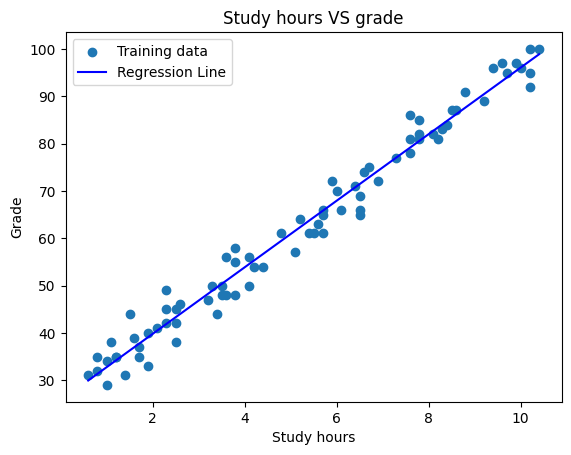

<Figure size 640x480 with 0 Axes>

In [43]:
plt.Figure(figsize=(10,10))
plt.scatter(X_train,y_train, label="Training data")
X_sorted=np.sort(X_train)
y_sorted=model.predict(X_sorted)
plt.plot(X_sorted, y_sorted, color='blue', label='Regression Line')

plt.xlabel("Study hours")
plt.ylabel("Grade")
plt.title("Study hours VS grade")
plt.legend()
plt.show()
plt.savefig('study hours-vs-grade.png')

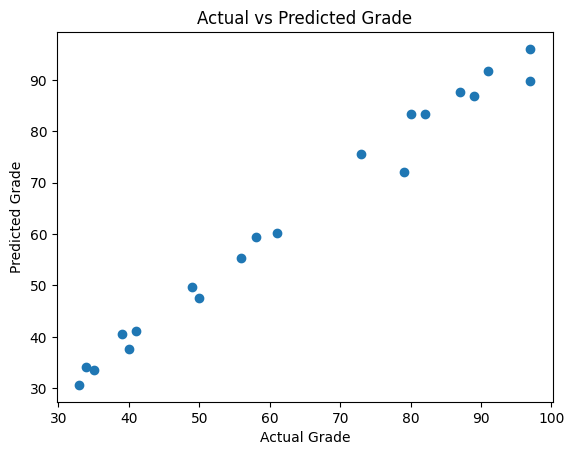

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Grade")

plt.show()

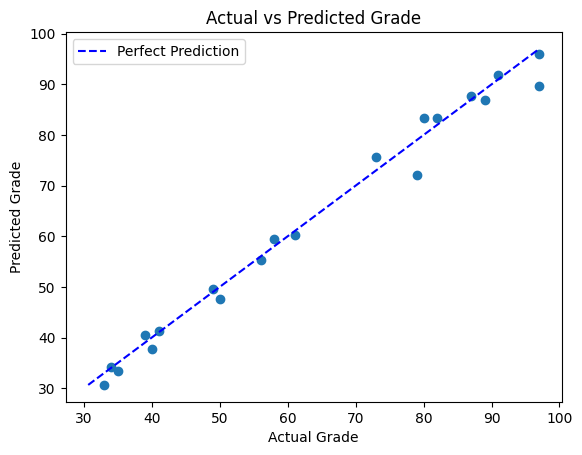

<Figure size 640x480 with 0 Axes>

In [44]:
plt.scatter(y_test, y_pred)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="blue",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Grade")

plt.legend()
plt.show()
plt.savefig('Actual vs Predicted Grade.png')

In [42]:
print(f"Regression Equation: Grade = {model.m:.4f} × Study_Hours + {model.b:.4f}")

Regression Equation: Grade = 7.0354 × Study_Hours + 25.7090
